# Import semua resource yang digunakan

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelBinarizer
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud,STOPWORDS
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize,sent_tokenize
from bs4 import BeautifulSoup
import spacy
import re,string,unicodedata
from nltk.tokenize.toktok import ToktokTokenizer
from nltk.stem import LancasterStemmer,WordNetLemmatizer
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from textblob import TextBlob
from textblob import Word
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory


import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('images', exist_ok=True)


### 1.Load Dataset

In [2]:
df = pd.read_csv('data/20191002-reviews.csv')
df.head()

,itemId,category,name,rating,originalRating,reviewTitle,reviewContent,likeCount,upVotes,downVotes,helpful,relevanceScore,boughtDate,clientType,retrievedDate
0,100002528,beli-harddisk-eksternal,Kamal U.,5,NaN,NaN,bagus mantap dah sesui pesanan,0,0,0,True,26.51,09 Apr 2019,androidApp,2019-10-02
1,100002528,beli-harddisk-eksternal,yofanca m.,4,NaN,NaN,"Bagus, sesuai foto",0,0,0,True,22.49,24 Sep 2017,androidApp,2019-10-02
2,100002528,beli-harddisk-eksternal,Lazada Customer,5,NaN,ok mantaaapppp barang sesuai pesanan.. good,okkkkk mantaaaaaaapppp ... goood,0,0,0,True,21.50,04 Apr 2018,androidApp,2019-10-02
3,100002528,beli-harddisk-eksternal,Lazada Customer,4,NaN,NaN,bagus sesuai,0,0,0,True,20.51,22 Sep 2017,androidApp,2019-10-02
4,100002528,beli-harddisk-eksternal,Yosep M.,5,NaN,NaN,NaN,0,0,0,True,16.01,17 Agu 2018,androidApp,2019-10-02


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 203787 entries, 0 to 203786
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   itemId          203787 non-null  int64  
 1   category        203787 non-null  str    
 2   name            203787 non-null  str    
 3   rating          203787 non-null  int64  
 4   originalRating  8 non-null       float64
 5   reviewTitle     23399 non-null   str    
 6   reviewContent   107029 non-null  str    
 7   likeCount       203787 non-null  int64  
 8   upVotes         203787 non-null  int64  
 9   downVotes       203787 non-null  int64  
 10  helpful         203787 non-null  bool   
 11  relevanceScore  203787 non-null  float64
 12  boughtDate      196680 non-null  str    
 13  clientType      203787 non-null  str    
 14  retrievedDate   203787 non-null  str    
dtypes: bool(1), float64(2), int64(5), str(7)
memory usage: 22.0 MB


In [4]:
df.shape

(203787, 15)

### 2. EDA awal

#### 2.1 statistik deskriptif variabel numerik

In [5]:
df.describe()

,itemId,rating,originalRating,likeCount,upVotes,downVotes,relevanceScore
count,2.037870e+05,203787.000000,8.0,203787.000000,203787.000000,203787.000000,203787.000000
mean,2.836479e+08,4.603238,1.0,0.668634,0.668634,0.164638,25.097394
std,1.726207e+08,0.991164,0.0,12.192433,12.192433,2.013273,9.602434
min,6.068000e+03,1.000000,1.0,-1.000000,-1.000000,0.000000,0.960000
25%,1.600086e+08,5.000000,1.0,0.000000,0.000000,0.000000,18.010000
50%,3.541160e+08,5.000000,1.0,0.000000,0.000000,0.000000,23.510000
75%,4.147421e+08,5.000000,1.0,0.000000,0.000000,0.000000,29.670000
max,7.242170e+08,5.000000,1.0,1776.000000,1776.000000,111.000000,76.500000


#### 2.2 cek mising value

In [6]:
df.isnull().sum()

itemId                 0
category               0
name                   0
rating                 0
originalRating    203779
reviewTitle       180388
reviewContent      96758
likeCount              0
upVotes                0
downVotes              0
helpful                0
relevanceScore         0
boughtDate          7107
clientType             0
retrievedDate          0
dtype: int64

#### 2.3. cek data duplikat

In [7]:
df.duplicated().sum()

np.int64(3113)

#### 2.4. Disttribusi Rating

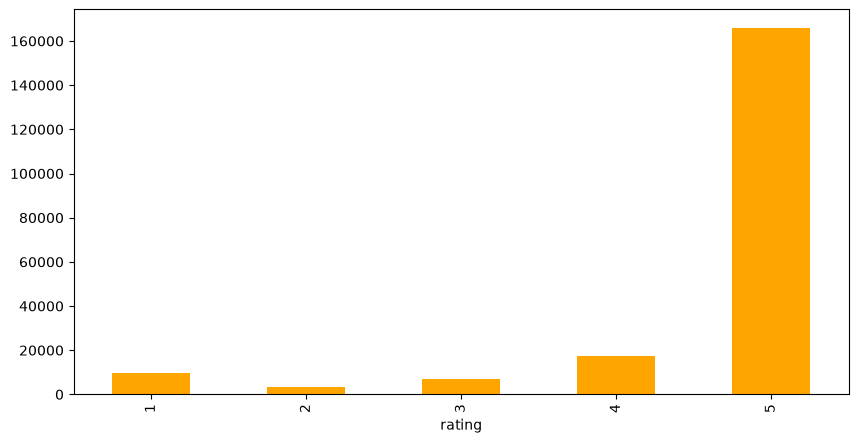

In [8]:
df['rating'].value_counts().sort_index().plot(kind='bar',figsize=(10,5),color='orange')
plt.savefig('images/rating_distribution.png')

### 3. Data Cleaning

#### 3.1. menangani missing value pada teks
`reviewTitle` dan `reviewContent` digabung. Review yang hanya berisi rating (tanpa teks) tidak bisa dipakai untuk analisis teks, jadi dibuang.

In [9]:
df['reviewTitle'] = df['reviewTitle'].fillna('')
df['reviewContent'] = df['reviewContent'].fillna('')

#gabungkan
df['text'] = (df['reviewTitle'] + ' ' + df['reviewContent']).str.strip()
df['text'].head()

0                      bagus  mantap dah sesui pesanan
1                                   Bagus, sesuai foto
2    ok mantaaapppp barang sesuai pesanan.. good ok...
3                                         bagus sesuai
4                                                     
Name: text, dtype: str

In [10]:
df[['reviewTitle', 'reviewContent', 'text']].head()

,reviewTitle,reviewContent,text
0,,bagus mantap dah sesui pesanan,bagus mantap dah sesui pesanan
1,,"Bagus, sesuai foto","Bagus, sesuai foto"
2,ok mantaaapppp barang sesuai pesanan.. good,okkkkk mantaaaaaaapppp ... goood,ok mantaaapppp barang sesuai pesanan.. good ok...
3,,bagus sesuai,bagus sesuai
4,,,


#### 3.2. cek text kosong

In [11]:
print("Text kosong :", (df['text'] == '').sum())

Text kosong : 94432


#### 3.3. lihat text kosong

In [12]:
df[df['text'] == ''][['rating', 'reviewTitle', 'reviewContent']].head(10)

,rating,reviewTitle,reviewContent
4,5,,
5,5,,
6,5,,
10,5,,
18,5,,
25,5,,
26,3,,
27,5,,
28,5,,
31,5,,


#### 3.4. menghapus text kosong

In [13]:
sebelum = len(df)
df = df[df['text'] != ''].copy()

print("Sebelum :", sebelum)
print("Sesudah :", len(df))
print("Dihapus :", sebelum - len(df))

rekap = {}
rekap['Data mentah'] = sebelum
rekap['Setelah hapus teks kosong'] = len(df)

Sebelum : 203787
Sesudah : 109355
Dihapus : 94432


In [14]:
df.shape

(109355, 16)

In [14]:
df.isnull().sum()

itemId                 0
category               0
name                   0
rating                 0
originalRating    109347
reviewTitle            0
reviewContent          0
likeCount              0
upVotes                0
downVotes              0
helpful                0
relevanceScore         0
boughtDate          6749
clientType             0
retrievedDate          0
text                   0
dtype: int64

### 4. Membuat label sentimen

gunkan rating dengan aturan:
- Rating 1–2 → Negative
- Rating 3   → Neutral
- Rating 4–5 → Positive

In [15]:
def sentiment_label(rating):
    if rating >= 4:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    else:
        return 'negative'

df['sentiment'] = df['rating'].apply(sentiment_label)
df[['rating', 'sentiment']].head()

,rating,sentiment
0,5,positive
1,4,positive
2,5,positive
3,4,positive
7,1,negative


### 5. EDA Lanjutan

lihat distribusi label yang akan digunakan model

In [16]:
df['sentiment'].value_counts()

sentiment
positive    95369
negative     9451
neutral      4535
Name: count, dtype: int64

In [17]:
df['sentiment'].value_counts(normalize=True) * 100

sentiment
positive    87.210461
negative     8.642495
neutral      4.147044
Name: proportion, dtype: float64

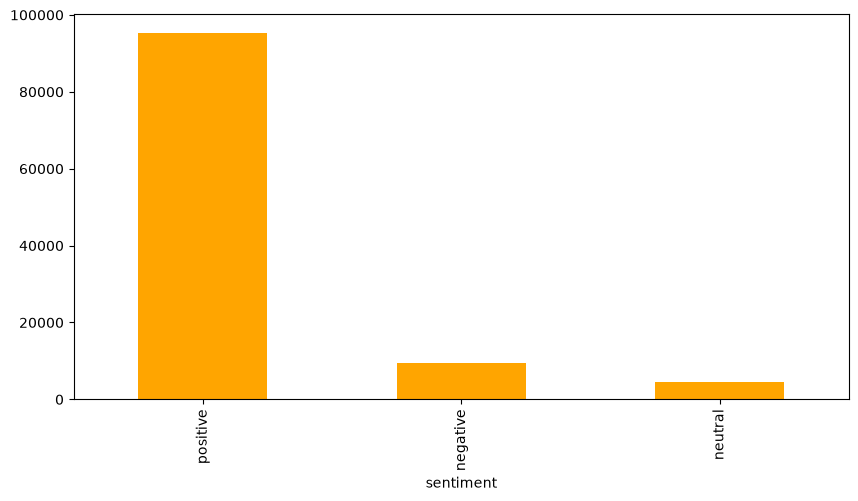

In [18]:
df['sentiment'].value_counts().plot(kind='bar',figsize=(10,5),color='orange')
plt.savefig('images/sentiment_distribution.png')


### 6. Text Preprocessing
Urutan: lowercase → hapus URL/HTML/angka/simbol → **kecilkan huruf berulang** → rapikan spasi.

In [19]:
def clean_text(text):
    text = str(text)

    #lowercase
    text = text.lower()
    #normalisasi unicode
    text = re.sub(r'(.)\1{2,}', r'\1', text)   
    #hapus url
    text = re.sub(r'http\S+|www\S+', ' ', text)
    #hapus html 
    text = re.sub(r'<.*?>', ' ', text)
    # hapus angka
    text = re.sub(r'\d+', ' ', text)
    # hapus karakter selain huruf
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    #hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()


,text,clean_text
0,bagus mantap dah sesui pesanan,bagus mantap dah sesui pesanan
1,"Bagus, sesuai foto",bagus sesuai foto
2,ok mantaaapppp barang sesuai pesanan.. good ok...,ok mantap barang sesuai pesanan good ok mantap...
3,bagus sesuai,bagus sesuai
7,ada pengirimn ntb bima bima,ada pengirimn ntb bima bima


### 7. STOPWORD REMOVAL

In [20]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

stopword_factory = StopWordRemoverFactory()

# kata yang dipertahankan karena membawa makna sentimen
dipertahankan = {'tidak', 'tak', 'bukan', 'belum', 'nggak', 'tanpa', 'ok'}

stopword = set(
    w for w in stopword_factory.get_stop_words()
    if w not in dipertahankan
)
print("Jumlah stopword:", len(stopword))

Jumlah stopword: 118


#### 7.1 Fungsi stopword removal

In [21]:
def remove_stopword(text):
    words = text.split()
    words = [word for word in words if word not in stopword]
    return ' '.join(words)

df['no_stopword'] = df['clean_text'].apply(remove_stopword)
df[['clean_text', 'no_stopword']].head()

,clean_text,no_stopword
0,bagus mantap dah sesui pesanan,bagus mantap dah sesui pesanan
1,bagus sesuai foto,bagus sesuai foto
2,ok mantap barang sesuai pesanan good ok mantap...,ok mantap barang sesuai pesanan good ok mantap...
3,bagus sesuai,bagus sesuai
7,ada pengirimn ntb bima bima,pengirimn ntb bima bima


### 8. Stemming

pada tahap ini setiap kata dikembalikan ke kata dasarnya

In [23]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

stemmer = StemmerFactory().create_stemmer()

unik = df['no_stopword'].unique()
print("Teks unik yang di-stem:", len(unik))

peta = {t: stemmer.stem(t) for t in unik}
df['processed_text'] = df['no_stopword'].map(peta)

df[['no_stopword', 'processed_text']].head()

Teks unik yang di-stem: 37144


,no_stopword,processed_text
0,bagus mantap dah sesui pesanan,bagus mantap dah sesui pesan
1,bagus sesuai foto,bagus sesuai foto
2,ok mantap barang sesuai pesanan good ok mantap...,ok mantap barang sesuai pesan good ok mantap god
3,bagus sesuai,bagus sesuai
7,pengirimn ntb bima bima,pengirimn ntb bima bima


### 9. cek hasil preprocessing


Review yang isinya hanya emoji/simbol/stopword jadi kosong setelah preprocessing dan harus dibuang.

In [24]:
df[['text', 'clean_text', 'no_stopword', 'processed_text','sentiment']].head(10)

,text,clean_text,no_stopword,processed_text,sentiment
0,bagus mantap dah sesui pesanan,bagus mantap dah sesui pesanan,bagus mantap dah sesui pesanan,bagus mantap dah sesui pesan,positive
1,"Bagus, sesuai foto",bagus sesuai foto,bagus sesuai foto,bagus sesuai foto,positive
2,ok mantaaapppp barang sesuai pesanan.. good ok...,ok mantap barang sesuai pesanan good ok mantap...,ok mantap barang sesuai pesanan good ok mantap...,ok mantap barang sesuai pesan good ok mantap god,positive
3,bagus sesuai,bagus sesuai,bagus sesuai,bagus sesuai,positive
7,ada pengirimn ntb bima bima,ada pengirimn ntb bima bima,pengirimn ntb bima bima,pengirimn ntb bima bima,negative
8,baru 10 bulan layarnya dah bergaris,baru bulan layarnya dah bergaris,baru bulan layarnya dah bergaris,baru bulan layar dah gar,negative
9,"Barang bagus sesuai specs Pesan rabu sore,ming...",barang bagus sesuai specs pesan rabu sore ming...,barang bagus sesuai specs pesan rabu sore ming...,barang bagus sesuai specs pesan rabu sore ming...,positive
11,Ini cicil pake apa? Mau tanya ini cicilnya pak...,ini cicil pake apa mau tanya ini cicilnya pake...,cicil pake apa mau tanya cicilnya pake apa cc bkn,cicil pake apa mau tanya cicil pake apa cc bkn,negative
12,Beli cash sesuai Harga di atas Apakah TV. Tsb....,beli cash sesuai harga di atas apakah tv tsb s...,beli cash sesuai harga atas tv tsb suda anti g...,beli cash sesuai harga atas tv tsb suda anti g...,positive
13,Pesanan tidak tepat waktu Pengirim barang tida...,pesanan tidak tepat waktu pengirim barang tida...,pesanan tidak tepat waktu pengirim barang tida...,pesan tidak tepat waktu kirim barang tidak ses...,negative


In [25]:
df.shape

(109355, 20)

#### 10. Data cleaning

#### 10.1 cek text dan tangani kosong

cek

In [26]:
print('processed text kosong:',(df['processed_text'].str.strip()=='').sum())

processed text kosong: 356


In [27]:
df[df['processed_text'].str.strip() == ''].head()

,itemId,category,name,rating,originalRating,reviewTitle,reviewContent,likeCount,upVotes,downVotes,helpful,relevanceScore,boughtDate,clientType,retrievedDate,text,sentiment,clean_text,no_stopword,processed_text
86,100034104,beli-harddisk-eksternal,Lazada Customer,5,NaN,,👍👍👍,0,0,0,True,29.83,22 Agu 2019,androidApp,2019-10-02,👍👍👍,positive,,,
309,100094942,beli-harddisk-eksternal,Rusli C.,5,NaN,,sudah sampaiii,1,1,0,True,24.99,09 Sep 2018,androidApp,2019-10-02,sudah sampaiii,positive,sudah sampai,,
851,101528155,beli-harddisk-eksternal,.,2,NaN,.,.,0,0,0,True,2.41,NaN,mobile-app,2019-10-02,. .,negative,,,
2163,103377776,beli-harddisk-eksternal,M F.,5,NaN,,1👍,0,0,0,True,16.01,12 Nov 2018,androidApp,2019-10-02,1👍,positive,,,
2782,104207424,beli-harddisk-eksternal,nulia I.,5,NaN,,👍,0,0,0,True,19.01,02 Mei 2019,androidApp,2019-10-02,👍,positive,,,


tangani

In [28]:
df = df[df['processed_text'].str.strip() != ''].copy()
print("Jumlah data setelah hapus processed_text kosong:", len(df))
rekap['Setelah hapus processed_text kosong'] = len(df)

Jumlah data setelah hapus processed_text kosong: 108999


simpan hasil

In [29]:
df.to_csv('data/lazada_processed.csv', index=False)
df_full = df   # dipakai untuk modeling (duplikat tetap ada)
print(df_full.shape)

(108999, 20)


In [22]:
import pandas as pd

df_full= pd.read_csv('data/lazada_processed.csv',
                      usecols=['processed_text', 'sentiment'])

# jaga-jaga: teks kosong terbaca sebagai NaN saat load CSV
df_full = df_full.dropna(subset=['processed_text'])
df_full = df_full[df_full['processed_text'].str.strip() != ''].reset_index(drop=True)

print(df_full.shape)
print(df_full['sentiment'].value_counts())
df_full.head()

(108999, 2)
sentiment
positive    95046
negative     9422
neutral      4531
Name: count, dtype: int64


,sentiment,processed_text
0,positive,bagus mantap dah sesui pesan
1,positive,bagus sesuai foto
2,positive,ok mantap barang sesuai pesan good ok mantap god
3,positive,bagus sesuai
4,negative,pengirimn ntb bima bima


#### 9.2 cek text duplikat

dalam hal ini ada dua kasus yg harus dibedakan:
- kasus a Teks sama, label sama. Ini duplikat murni, aman dibuang.
- kasus b Teks sama, label berbeda. Contohnya "bagus" muncul dengan rating 5 dan rating 3. Ini label yang bertentangan.


dalam model ini **Duplikat sengaja dipertahankan**: ulasan pendek seperti "bagus" memang sering muncul di dunia nyata.

##### kasus a

In [23]:
print('processed text duplikat:',df_full['processed_text'].duplicated().sum())

processed text duplikat: 72077


##### kasus b

In [24]:
konflik=(df_full.groupby('processed_text')['sentiment'].nunique())
konflik=konflik[konflik>1]
print('text dengan label bertentangan:', len(konflik))

text dengan label bertentangan: 101


text yang paling sering muncul

In [25]:
df_full['processed_text'].value_counts().head(10)

processed_text
mantap          1282
bagus           1165
good             721
ok               545
mantul           375
barang bagus     374
lima bintang     206
sip              158
puas             151
moga awet        147
Name: count, dtype: int64

### 11. Split data


Semua baris dengan teks yang sama dijadikan **satu grup**, lalu satu grup masuk seluruhnya ke train **atau** seluruhnya ke test.
Dengan begini tidak ada teks yang sama di kedua sisi, tetapi test tetap punya distribusi nyata (termasuk duplikat).
`StratifiedGroupKFold(n_splits=5)` → test ≈ 20%.

In [26]:
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.model_selection import learning_curve

In [27]:
X = df_full['processed_text']
y = df_full['sentiment']
groups = df_full['processed_text']

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(sgkf.split(X, y, groups))

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_test,  y_test  = X.iloc[test_idx],  y.iloc[test_idx]

print("Data training:", len(X_train), "| Data testing:", len(X_test))
print("Teks yang bocor (harus 0):", len(set(X_train) & set(X_test)))

print("\nProporsi training (%):"); print((y_train.value_counts(normalize=True) * 100).round(2))
print("\nProporsi testing (%):");  print((y_test.value_counts(normalize=True) * 100).round(2))

Data training: 87200 | Data testing: 21799
Teks yang bocor (harus 0): 0

Proporsi training (%):
sentiment
positive    87.20
negative     8.64
neutral      4.16
Name: proportion, dtype: float64

Proporsi testing (%):
sentiment
positive    87.20
negative     8.64
neutral      4.16
Name: proportion, dtype: float64


In [28]:
y_train.value_counts()

sentiment
positive    76037
negative     7538
neutral      3625
Name: count, dtype: int64

In [29]:
y_test.value_counts()

sentiment
positive    19009
negative     1884
neutral       906
Name: count, dtype: int64

#### 11.1 Pengaman data leakage
Pada skenario B duplikat di train **boleh ada** (memang dipertahankan). Yang dilarang hanya teks yang sama di train dan test.

In [30]:
assert len(set(X_train) & set(X_test)) == 0, 'Ada teks bocor train-test'
print('OK, tidak ada teks bocor. X_train:', len(X_train), '| X_test:', len(X_test))
print('Duplikat di train (normal untuk skenario B):', X_train.duplicated().sum())

OK, tidak ada teks bocor. X_train: 87200 | X_test: 21799
Duplikat di train (normal untuk skenario B): 57661


#### 11.2 GridSearchCV (untuk mencari parameter terbaik)

In [31]:
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression

param_grid = {
    'vec__ngram_range': [(1, 1), (1, 2)],
    'vec__min_df': [2, 5],
    'clf__C': [0.03, 0.1, 0.3, 1],
}
cv_tuning = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

def buat_pipe(vec_cls):
    return Pipeline([
        ('vec', vec_cls(max_features=50000)),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ])

kandidat_tuned = {}
for nama, vec_cls in [('LogReg + BoW', CountVectorizer), ('LogReg + TF-IDF', TfidfVectorizer)]:
    gs = GridSearchCV(buat_pipe(vec_cls), param_grid, scoring='f1_macro',
                      cv=cv_tuning, n_jobs=1, verbose=1)
    gs.fit(X_train, y_train, groups=X_train)      
    kandidat_tuned[nama] = gs.best_estimator_
    print(nama, '|', gs.best_params_, '| macro F1 CV:', round(gs.best_score_, 4))

kandidat = kandidat_tuned     

Fitting 3 folds for each of 16 candidates, totalling 48 fits
LogReg + BoW | {'clf__C': 0.03, 'vec__min_df': 2, 'vec__ngram_range': (1, 2)} | macro F1 CV: 0.59
Fitting 3 folds for each of 16 candidates, totalling 48 fits
LogReg + TF-IDF | {'clf__C': 1, 'vec__min_df': 2, 'vec__ngram_range': (1, 2)} | macro F1 CV: 0.5856


### 12. Modeling (baseline, sebelum tuning)


- Vektorisasi: Bag of Words, TF-IDF (unigram + bigram)
- `class_weight='balanced'` dipakai pada model yang mendukung

In [32]:
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, precision_recall_fscore_support
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#### 12.1 Vektorisasi Bag of Words (BoW)

In [33]:
bow = CountVectorizer(ngram_range=(1, 2), min_df=2, max_features=50000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)
print('Bow         : X_train_bow shape:', X_train_bow.shape, 'X_test_bow shape:', X_test_bow.shape)

Bow         : X_train_bow shape: (87200, 50000) X_test_bow shape: (21799, 50000)


#### 12.2 Train BoW

In [34]:
lr_bow = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_bow.fit(X_train_bow, y_train)
print('Iterasi BoW     :', lr_bow.n_iter_)

Iterasi BoW     : [115]


#### 12.3 Vektorisasi TF-IDF

In [35]:
tfidf=TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=50000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print('TF-IDF       : X_train_tfidf shape:', X_train_tfidf.shape, 'X_test_tfidf shape:', X_test_tfidf.shape)

TF-IDF       : X_train_tfidf shape: (87200, 50000) X_test_tfidf shape: (21799, 50000)


#### 12.4 Train TF-IDF

In [36]:
lr_tfidf = LogisticRegression(max_iter=1000, random_state=42,class_weight='balanced')
lr_tfidf.fit(X_train_tfidf, y_train)
print('Iterasi TF-IDF  :', lr_tfidf.n_iter_)

Iterasi TF-IDF  : [128]


#### 12.5 Model hasil tuning (dari GridSearchCV)
Model tuned sudah terlatih oleh GridSearchCV (`refit=True`), jadi tidak perlu `fit` lagi di sini.

In [37]:
for nama, pipe in kandidat_tuned.items():
    vec = pipe.named_steps['vec']
    clf = pipe.named_steps['clf']
    print(f'{nama:16s} | C={clf.C} | min_df={vec.min_df} | '
          f'ngram={vec.ngram_range} | class_weight={clf.class_weight}')

LogReg + BoW     | C=0.03 | min_df=2 | ngram=(1, 2) | class_weight=balanced
LogReg + TF-IDF  | C=1 | min_df=2 | ngram=(1, 2) | class_weight=balanced


### 13. Evaluasi dan perbandingan hasil

#### 13.1 Baseline (test penuh)

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

labels = ['negative', 'neutral', 'positive']

pred_bow_base = lr_bow.predict(X_test_bow)
pred_tfidf_base = lr_tfidf.predict(X_test_tfidf)

print('==== Hasil prediksi BoW (baseline) ==')
print(classification_report(y_test, pred_bow_base, target_names=labels, zero_division=0))
print('==== Hasil prediksi TF-IDF (baseline) ==')
print(classification_report(y_test, pred_tfidf_base, target_names=labels, zero_division=0))

==== Hasil prediksi BoW (baseline) ==
              precision    recall  f1-score   support

    negative       0.58      0.69      0.63      1884
     neutral       0.17      0.22      0.19       906
    positive       0.95      0.92      0.94     19009

    accuracy                           0.87     21799
   macro avg       0.57      0.61      0.59     21799
weighted avg       0.89      0.87      0.88     21799

==== Hasil prediksi TF-IDF (baseline) ==
              precision    recall  f1-score   support

    negative       0.57      0.76      0.65      1884
     neutral       0.16      0.27      0.20       906
    positive       0.96      0.90      0.93     19009

    accuracy                           0.86     21799
   macro avg       0.56      0.64      0.59     21799
weighted avg       0.90      0.86      0.88     21799



#### 13.2 Tuned (test penuh)

In [39]:
labels = ['negative', 'neutral', 'positive']

pred_bow = kandidat_tuned['LogReg + BoW'].predict(X_test)
pred_tfidf = kandidat_tuned['LogReg + TF-IDF'].predict(X_test)

print('==== Hasil prediksi BoW (tuned) ==')
print(classification_report(y_test, pred_bow, target_names=labels, zero_division=0))
print('==== Hasil prediksi TF-IDF (tuned) ==')
print(classification_report(y_test, pred_tfidf, target_names=labels, zero_division=0))

==== Hasil prediksi BoW (tuned) ==
              precision    recall  f1-score   support

    negative       0.57      0.75      0.64      1884
     neutral       0.16      0.30      0.21       906
    positive       0.97      0.90      0.93     19009

    accuracy                           0.86     21799
   macro avg       0.56      0.65      0.59     21799
weighted avg       0.90      0.86      0.87     21799

==== Hasil prediksi TF-IDF (tuned) ==
              precision    recall  f1-score   support

    negative       0.57      0.76      0.65      1884
     neutral       0.16      0.27      0.20       906
    positive       0.96      0.90      0.93     19009

    accuracy                           0.86     21799
   macro avg       0.56      0.64      0.59     21799
weighted avg       0.90      0.86      0.88     21799



#### 13.3 Ringkasan dan perbandingan (test penuh, realistis)

In [40]:
def ringkas(nama, y_true, y_pred):
    _, rec, _, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )
    return {
        'Model': nama,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Macro F1': f1_score(y_true, y_pred, labels=labels, average='macro', zero_division=0),
        'Weighted F1': f1_score(y_true, y_pred, labels=labels, average='weighted', zero_division=0),
        'Recall negative': rec[0],
        'Recall neutral': rec[1],
        'Recall positive': rec[2],
    }

perbandingan_penuh = pd.DataFrame([
    ringkas('LogReg + BoW (baseline)', y_test, pred_bow_base),
    ringkas('LogReg + TF-IDF (baseline)', y_test, pred_tfidf_base),
    ringkas('LogReg + BoW (tuned)', y_test, pred_bow),
    ringkas('LogReg + TF-IDF (tuned)', y_test, pred_tfidf),
]).set_index('Model').round(4)

perbandingan_penuh

,Accuracy,Macro F1,Weighted F1,Recall negative,Recall neutral,Recall positive
Model,,,,,,
LogReg + BoW (baseline),0.8709,0.5858,0.8783,0.6927,0.2185,0.9196
LogReg + TF-IDF (baseline),0.8610,0.5937,0.8757,0.7638,0.2660,0.8990
LogReg + BoW (tuned),0.8578,0.5934,0.8749,0.7479,0.2969,0.8954
LogReg + TF-IDF (tuned),0.8610,0.5937,0.8757,0.7638,0.2660,0.8990


#### 13.4 Perbandingan pada test unik (kasus sulit)
Skor di atas dipengaruhi banyaknya ulasan pendek yang mudah ditebak. Di sini test dibuang duplikatnya (hanya test, bukan train) supaya sebanding dengan skenario A.

In [41]:
mask_unik = ~X_test.duplicated().values
print(f'Test penuh: {len(X_test):,} | Test unik: {mask_unik.sum():,}')

perbandingan_unik = pd.DataFrame([
    ringkas('LogReg + BoW (baseline)', y_test[mask_unik], pred_bow_base[mask_unik]),
    ringkas('LogReg + TF-IDF (baseline)', y_test[mask_unik], pred_tfidf_base[mask_unik]),
    ringkas('LogReg + BoW (tuned)', y_test[mask_unik], pred_bow[mask_unik]),
    ringkas('LogReg + TF-IDF (tuned)', y_test[mask_unik], pred_tfidf[mask_unik]),
]).set_index('Model').round(4)

perbandingan_unik

Test penuh: 21,799 | Test unik: 7,383


,Accuracy,Macro F1,Weighted F1,Recall negative,Recall neutral,Recall positive
Model,,,,,,
LogReg + BoW (baseline),0.8598,0.5860,0.8692,0.7058,0.2178,0.9099
LogReg + TF-IDF (baseline),0.8528,0.5975,0.8686,0.7737,0.2699,0.8915
LogReg + BoW (tuned),0.8471,0.5954,0.8659,0.7610,0.3006,0.8847
LogReg + TF-IDF (tuned),0.8528,0.5975,0.8686,0.7737,0.2699,0.8915


### 14. Confusion matrix

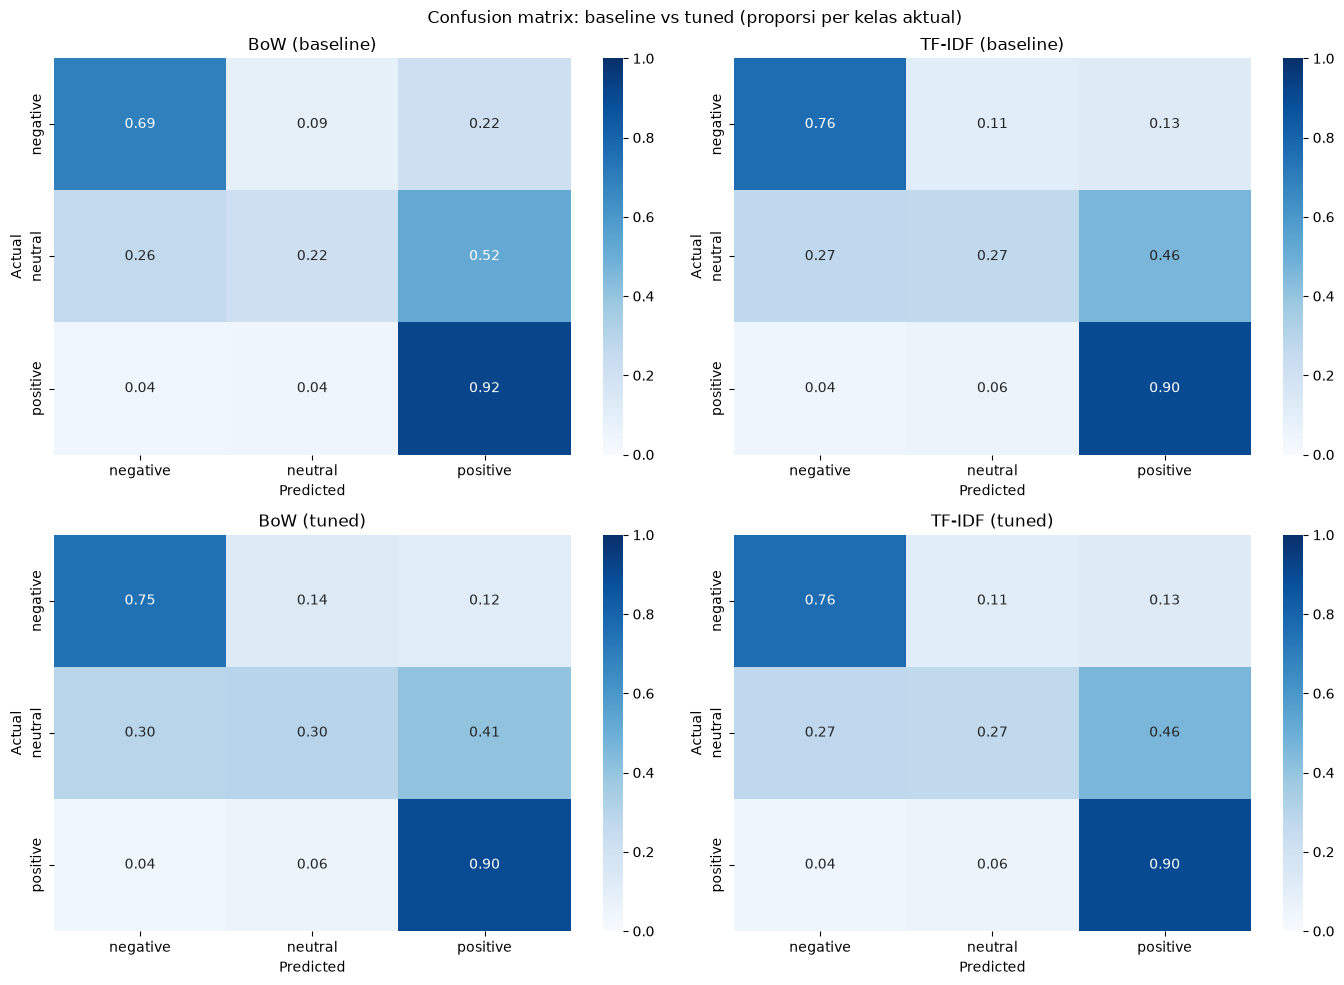

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

pasangan = [
    ('BoW (baseline)', pred_bow_base),   ('TF-IDF (baseline)', pred_tfidf_base),
    ('BoW (tuned)', pred_bow),           ('TF-IDF (tuned)', pred_tfidf),
]

for a, (nama, pred) in zip(axes.ravel(), pasangan):
    cm = confusion_matrix(y_test, pred, labels=labels, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
                xticklabels=labels, yticklabels=labels, ax=a)
    a.set_title(nama)
    a.set_xlabel('Predicted')
    a.set_ylabel('Actual')

fig.suptitle('Confusion matrix: baseline vs tuned (proporsi per kelas aktual)')
plt.tight_layout()
plt.savefig('images/confusion_matrix_B_baseline_vs_tuned.png', dpi=300, bbox_inches='tight')   # di notebook B: ..._B_...
plt.show()

### 15. Cross Validation
Pakai splitter yang sama dan mengirim `groups`, sehingga tiap fold juga bebas leakage.

In [44]:
from sklearn.model_selection import StratifiedGroupKFold, cross_validate

cv_group = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'accuracy': 'accuracy', 'macro_f1': 'f1_macro'}

baris = []
for nama, pipe in kandidat_tuned.items():
    cv = cross_validate(pipe, X_train, y_train, groups=X_train, cv=cv_group,
                        scoring=scoring, n_jobs=1, return_train_score=True)
    baris.append({
        'Model': nama,
        'Accuracy val': cv['test_accuracy'].mean(),
        'Macro F1 train': cv['train_macro_f1'].mean(),
        'Macro F1 val': cv['test_macro_f1'].mean(),
        'Gap (train - val)': cv['train_macro_f1'].mean() - cv['test_macro_f1'].mean(),
        'Macro F1 SD (val)': cv['test_macro_f1'].std(),
    })

hasil_cv = pd.DataFrame(baris).set_index('Model').round(4)
hasil_cv

,Accuracy val,Macro F1 train,Macro F1 val,Gap (train - val),Macro F1 SD (val)
Model,,,,,
LogReg + BoW,0.8577,0.8025,0.5975,0.2050,0.0048
LogReg + TF-IDF,0.8650,0.8754,0.5907,0.2848,0.0076


### 16. Word cloud per sentimen

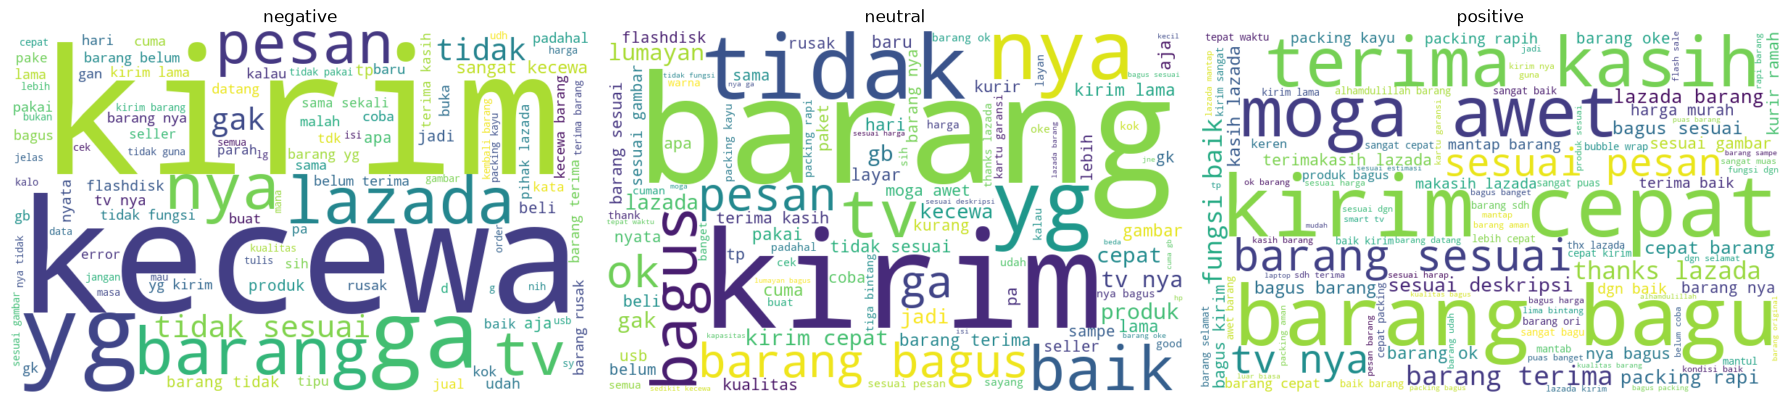

In [45]:
from wordcloud import WordCloud

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

for a, kelas in zip(ax, labels):
    teks = ' '.join(df_full.loc[df_full['sentiment'] == kelas, 'processed_text'])
    wc = WordCloud(width=800, height=500, max_words=100,
                   background_color='white').generate(teks)
    a.imshow(wc, interpolation='bilinear')
    a.set_title(kelas)
    a.axis('off')

plt.tight_layout()
plt.savefig('images/wordcloud_B_group.png', dpi=300, bbox_inches='tight')
plt.show()

### 17. Learning Kurve

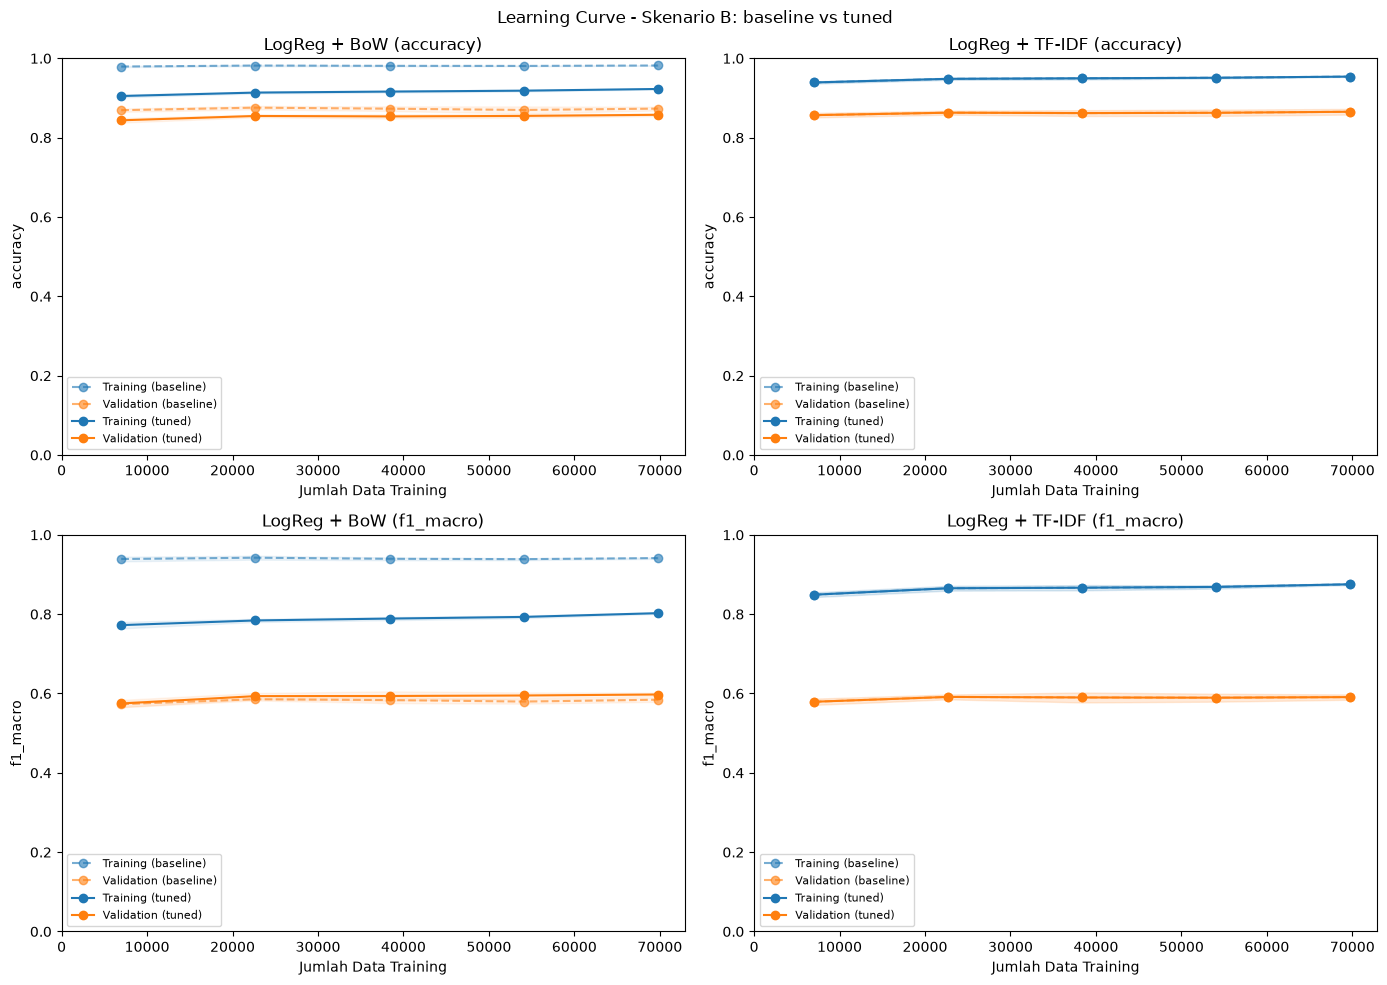

Training  Validation     Gap
Model           Metrik   Versi                                 
LogReg + BoW    accuracy baseline    0.9820      0.8732  0.1088
                         tuned       0.9228      0.8577  0.0651
LogReg + TF-IDF accuracy baseline    0.9540      0.8653  0.0887
                         tuned       0.9540      0.8653  0.0887
LogReg + BoW    f1_macro baseline    0.9414      0.5843  0.3570
                         tuned       0.8025      0.5975  0.2050
LogReg + TF-IDF f1_macro baseline    0.8753      0.5909  0.2844
                         tuned       0.8753      0.5909  0.2844

In [46]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve

os.makedirs('images', exist_ok=True)

# baseline = pengaturan yang sama persis dengan section 12 (C=1 default)
kandidat_baseline = {
    'LogReg + BoW': Pipeline([
        ('vec', CountVectorizer(ngram_range=(1, 2), min_df=2, max_features=50000)),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ]),
    'LogReg + TF-IDF': Pipeline([
        ('vec', TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=50000)),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ]),
}

def hitung_curve(pipe, X, y, cv, scoring, groups=None):
    sizes, tr, va = learning_curve(
        pipe, X, y, groups=groups, cv=cv, scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 5), shuffle=True,
        random_state=42, n_jobs=1)   # n_jobs=1 hemat RAM
    return sizes, tr.mean(axis=1), tr.std(axis=1), va.mean(axis=1), va.std(axis=1)

def plot_baseline_vs_tuned(kandidat_baseline, kandidat_tuned, X, y, cv, nama_file, judul,
                           groups=None, metrik=('accuracy', 'f1_macro')):
    nama_model = list(kandidat_tuned.keys())
    fig, axes = plt.subplots(len(metrik), len(nama_model),
                             figsize=(7 * len(nama_model), 5 * len(metrik)), squeeze=False)
    ringkasan = []

    for i, scoring in enumerate(metrik):
        for j, nama in enumerate(nama_model):
            ax = axes[i][j]
            for versi, pipe, gaya, alpha in [
                ('baseline', kandidat_baseline[nama], '--', 0.6),
                ('tuned',    kandidat_tuned[nama],    '-',  1.0),
            ]:
                sizes, trm, trs, vam, vas = hitung_curve(pipe, X, y, cv, scoring, groups)
                ax.plot(sizes, trm, gaya, marker='o', color='tab:blue',
                        alpha=alpha, label=f'Training ({versi})')
                ax.plot(sizes, vam, gaya, marker='o', color='tab:orange',
                        alpha=alpha, label=f'Validation ({versi})')
                ax.fill_between(sizes, trm - trs, trm + trs, color='tab:blue', alpha=0.08)
                ax.fill_between(sizes, vam - vas, vam + vas, color='tab:orange', alpha=0.08)
                ringkasan.append({
                    'Model': nama, 'Metrik': scoring, 'Versi': versi,
                    'Training': trm[-1], 'Validation': vam[-1], 'Gap': trm[-1] - vam[-1],
                })
            ax.set_title(f'{nama} ({scoring})')
            ax.set_xlabel('Jumlah Data Training')
            ax.set_ylabel(scoring)
            ax.set_xlim(0)
            ax.set_ylim(0, 1)
            ax.legend(fontsize=8)

    fig.suptitle(judul)
    plt.tight_layout()
    plt.savefig(nama_file, dpi=300, bbox_inches='tight')
    plt.show()
    return pd.DataFrame(ringkasan).set_index(['Model', 'Metrik', 'Versi']).round(4)


ringkasan_lc = plot_baseline_vs_tuned(
    kandidat_baseline, kandidat_tuned, X_train, y_train, cv=cv_group, groups=X_train,
    nama_file='images/learning_curve_B_baseline_vs_tuned.png',
    judul='Learning Curve - Skenario B: baseline vs tuned',
)
ringkasan_lc

In [47]:
print('Jumlah X_train       :', len(X_train))
print('Duplikat di X_train  :', X_train.duplicated().sum())
print('Teks bocor train-test:', len(set(X_train) & set(X_test)))

Jumlah X_train       : 87200
Duplikat di X_train  : 57661
Teks bocor train-test: 0
